In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Sample - Superstore.csv'

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

FileNotFoundError: [Errno 2] No such file or directory: 'Sample - Superstore.csv'

In [5]:
df = pd.read_csv("/mnt/data/Sample - Superstore.csv", encoding="latin1")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Sample - Superstore.csv'

In [6]:

df = pd.read_csv(r"C:\Users\prave\OneDrive\Documents\AI-Retail-Sales-Analytics\data\raw\Sample - Superstore.csv", encoding="latin1")

In [7]:
df["Month"] = df["Order Date"].dt.to_period("M")

AttributeError: Can only use .dt accessor with datetimelike values

In [8]:
# First convert the "Order Date" column to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Then extract the month period
df["Month"] = df["Order Date"].dt.to_period("M")

In [9]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

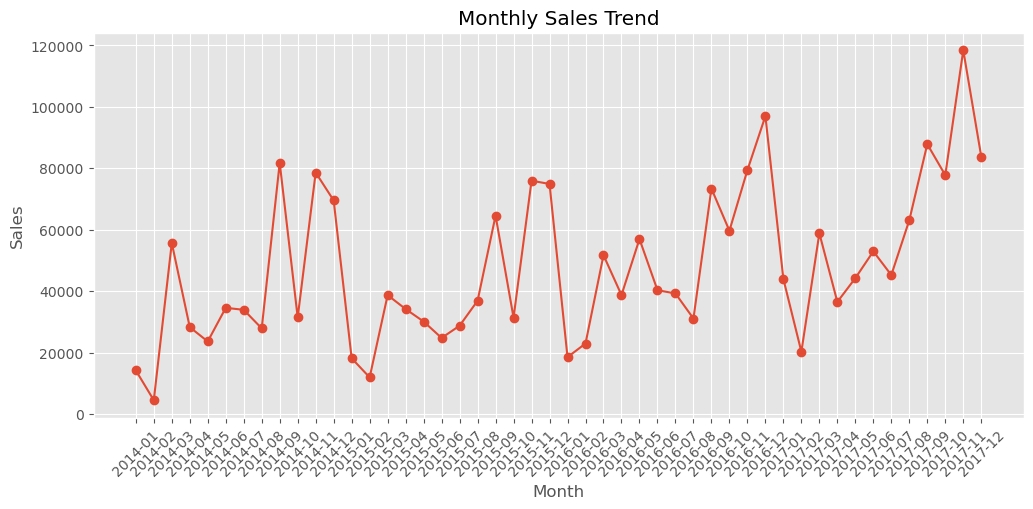

In [10]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [11]:
df["Year"] = df["Order Date"].dt.year

In [12]:
yearly_sales = df.groupby("Year")["Sales"].sum()
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

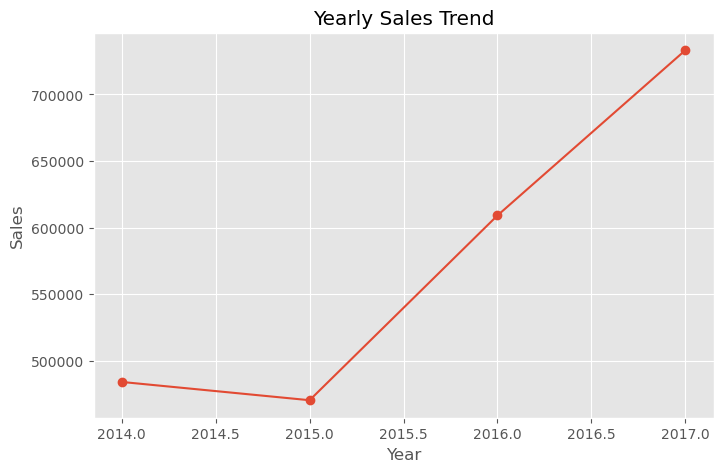

In [13]:
plt.figure(figsize=(8,5))

plt.plot(yearly_sales.index, yearly_sales.values, marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [14]:
region_profit = df.groupby("Region")["Profit"].sum()
region_profit

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

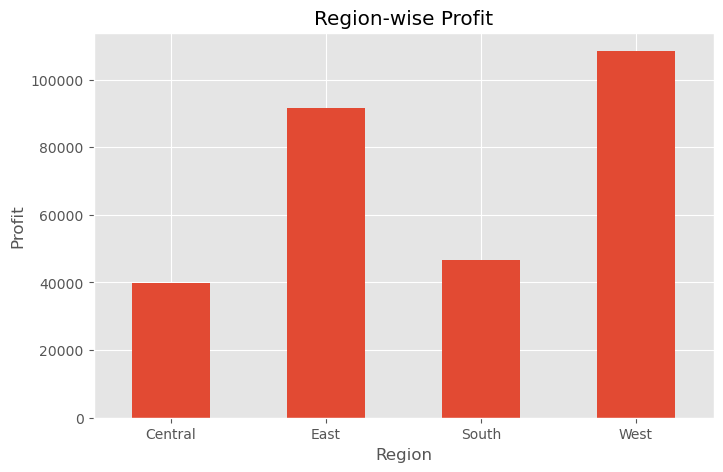

In [15]:
plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.grid(True)

plt.show()

In [16]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

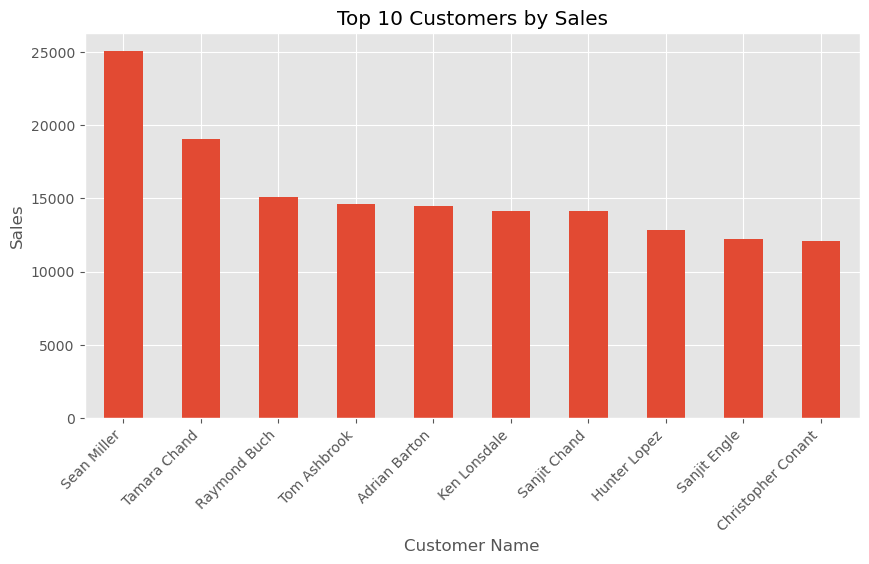

In [17]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")
plt.grid(True)

plt.show()

In [18]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

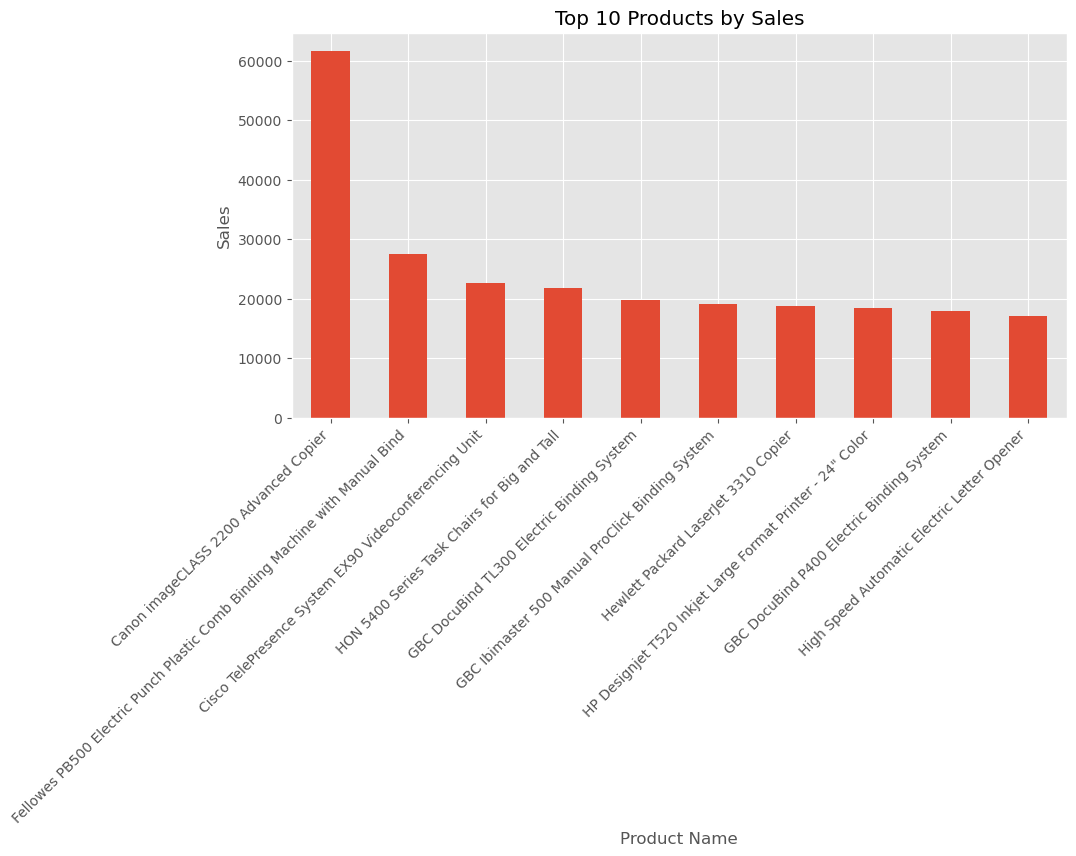

In [19]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")
plt.grid(True)

plt.show()

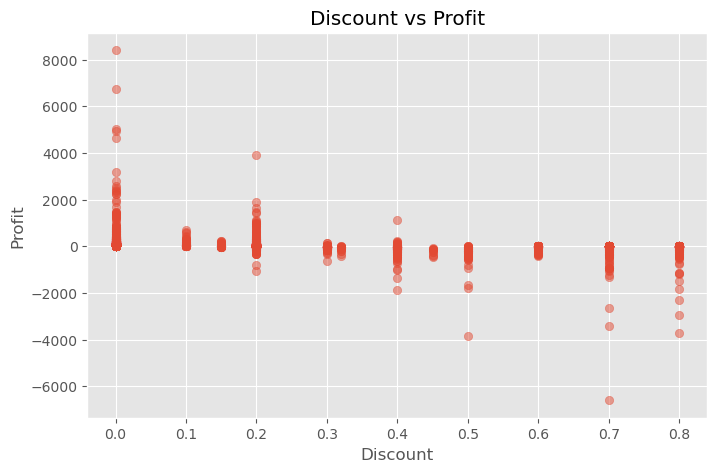

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)
plt.show()

In [21]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
state_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

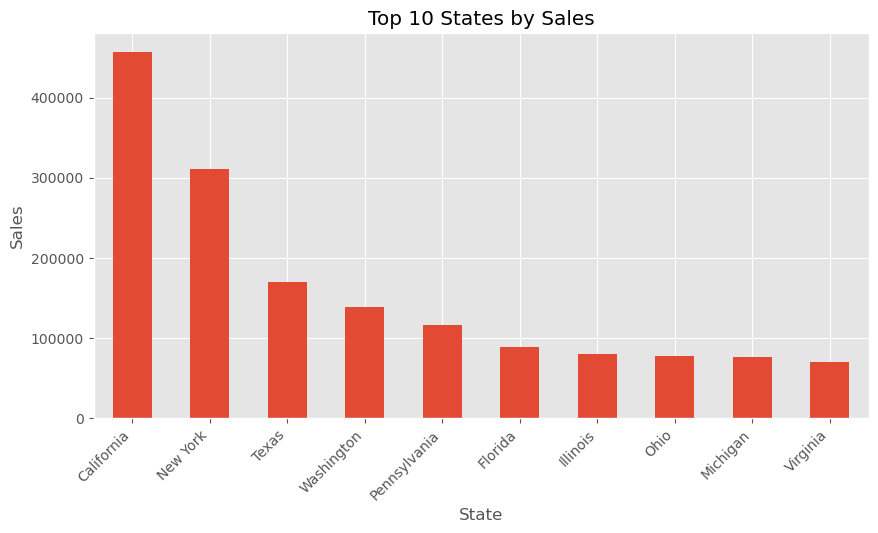

In [22]:
plt.figure(figsize=(10,5))

state_sales.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")
plt.grid(True)

plt.show()